### Proof of concept for derivations of CHMM in a Variational inference framework

##### Simple markov chain in order to test the predictive capacity of the derivations I've found for a PC free energy frame work. 
Since idk anything else that euler's method I'll use that. I could also implement something to do with a learning rate etc btu tbd with Fabian. \
Other option could be to copy the markov chain in the original CHMM paper as a POC for the PC method

Couple comments on notation : 
- Time is in T and tau 
- Transition matrix will thus be in A, and parametrization in a 
- Hidden state values are in Q, parametrization in h

In [1]:
## Libs 
import numpy as np
import numpy.random as rd
import scipy as sc
from tqdm import tqdm as tqdm
import seaborn as sns

In [2]:

## CHMM Toy model Dedieu et al 2019 - Matrix 

'''
Build a state machine that produces a sequence. Give clones accordingly
0,1,2,3 are signal nodes, separated by 3k-2 noise nodes, k=4 is first toy example
    split 0.5/0.5 into 1 into 1 into 0.5/0.5 into 1 into 1
0 to 4,5 to 6 to 7 to 8,9 to 1

matrix is thus 0,1,2,3 + 2*10 = 20 = 24 states in total. 24x24 transition matrix
first 2 are 0.5/0.5 then 1 1 then 0.5/0.5 etc

Columns are the start, rows the endpoint

TO DO : shift from 2 pairs of clones to cloning neighbors - inherently doesn't matter for A, just how I fill h and cA!!
'''

k = 4
dim = 4 + (3*k-2)*2
A = np.zeros(shape=(dim,dim))
A[4,0] = 0.5
A[5,0] = 0.5

A[0,1] = 0.5
A[2,1] = 0.5

A[14,2] = 0.5
A[15,2] = 0.5

A[0,3] = 0.5
A[2,3] = 0.5 


           
'''
Make chains, hook them up
'''
# Make the chains for noise and the corresponding clone
noise = 4 + np.arange(0,3*k-2)*1 # total noise cell tags, there are 2 of each as there are 2 clones of each
clones = np.arange(noise[-1] + 1, noise[-1] + 1 + 3*k-2) # could loop or soomething for generalization to common clone amounts
noise_pairs = np.array_split(noise,indices_or_sections=np.arange(2,len(noise),step=2)) # Allows to parse over the pairs and associate probabilities
clone_pairs = np.array_split(clones,indices_or_sections=np.arange(2,len(clones),step=2))

# Fill their Tmatrix
def fill_noise_chain(noise_pairs,A):
    progress = 1
    for inds in range(len(noise_pairs)-1):
        pair = noise_pairs[inds]
        next_pair = noise_pairs[inds+1]
        for i in pair:
            if progress%2 == 1 :
                A[next_pair[-2],i] = 1
            elif progress%2 == 0 :
                        
                if i%2 == 0: #first in the middle pair is always even 
                    A[i+1,i] = 1
                else :
                    A[next_pair[-2]:next_pair[-1]+1,i] = np.array([0.5,0.5])
        
        progress += 1 
    return

fill_noise_chain(noise_pairs,A)
fill_noise_chain(clone_pairs,A)

# Hook them up to their corresponding starts and ends
def hook_chain(noise_pairs,A,clone):
    if clone == 0:
        start = 0
        end = 1
    else : 
        start = 2
        end = 3
    start_p = noise_pairs[0]
    end_p = noise_pairs[-1]
    for i in start_p:
        A[i,start] =0.5
    
    if len(end_p) == 1:
        A[end,end_p[0]] = 1
    else :
        for i in end_p:
            A[end,i] =1
        
    
    return A

hook_chain(noise_pairs,A,0)
hook_chain(clone_pairs,A,1)

''' 
Encoder / decoder
Id() function
'''
def decoder(x):
    return x

def encoder(x,k=k):
    if x in np.arange(4,(3*k-2)+1):
        return x
    else :
        return x - (3*k-2)

'''
Generate sequence - 
'''

####################
## Training sequence
####################

# training sequence creation
position = 0
POS = np.arange(A.shape[0])

T = 10 # sequence length

seq = [np.int64(0)]

for t in tqdm(range(T)):
    position = rd.choice(a = POS, p = A[:,position]) #Update position according to transition matrix
    seq.append(encoder(position)) #Append decoded sequence
    
    
## Gradients for Inference and learning

''' 
Gradients for softmax prior and softmax transition matrix within clones. 
Gradients on the parametrization
'''

    # Grad clone/latent state
def error(Qnow,Qprev,Transition, eps=1e-6): #w/ smoothing for impossible transitions
    return -np.log(Qnow) + np.log(np.linalg.matmul(Transition,Qprev) + eps) + np.ones(shape=Qnow.shape)*2 #vector column 

def dh(Qnow,Qprev,Transition): # Free energy derivation for hidden states (E step)
    
    e = error(Qnow,Qprev,Transition)
    avg_e = np.ones(shape=e.shape)*np.linalg.matmul(Qnow.T,e) #vector for the average in the shape of e. Global inhibitory effect
    return np.clip(Qnow*(e-avg_e), -0.5, 0.5) #Clip gradient value for prior parametrization after smoothing in order to handle log pass of impossible events

    # Grad clones t-1 --> clones t transition matrix
def da(Qnow,Qprev,Transition,eps=1e-6): #Free energy derivation for transition probabilities (M step)
          
    fat_prev = np.full(shape=Transition.shape, fill_value=Qprev) #Enable vector operation matmul on Tq(t-1) to avoid something really unreadable. Maintains the shape of the objects. More memory, less work
    
    # print(Qprev)
    # print(fat_prev)
    # print(Transition)
    # return Qnow*((Qprev.T*Transition)/(np.linalg.matmul(Transition,fat_prev))-np.ones(shape=Transition.shape)) # See notes for equation explanation
    return Qnow*(np.clip((Qprev.T*Transition)/(np.linalg.matmul(Transition,fat_prev) + eps),-0.5,0.5)-Transition) # See notes for equation explanation


## Innitialization

# Initialize hidden states : softmax within clonal group/assembly
'''
h format has to become linear for simplicity. -- handle softmax ...
Contrary to over head 2 clones will now follow each other : 0,1,2,3,4,4,5,5,6,6,..,13,13
'''
n_clones = 2

dimensions = (A.shape[0]) # NB for now separate the clones in a row each for clarity

# Prepare latent state variables with a separation between the first 4 inds and then the rest
h_params_init = rd.normal(size=4) #Initialize randomly on gaussian
h_params_noise = rd.normal(size=noise.shape[0]*n_clones)
h_params = np.concatenate((h_params_init,h_params_noise))
h_params_pairs = np.split(h_params_noise,(h_params_noise.shape[0])/n_clones)

h = np.zeros(shape=h_params.shape)
    # Initialize first 4 states as 1 
h[0:4] = sc.special.softmax(h_params_init[np.newaxis],axis=0)
    # Initialize clone pairs
h[4:] = (sc.special.softmax(h_params_pairs,axis=1)).flatten()    
    
# Initialize transition matrix : softmax probability

a = rd.normal(size=(dim,dim))*0.01 #Normal initialization
cA = sc.special.softmax(a,axis=0)
# cA = A


100%|██████████| 10/10 [00:00<00:00, 12278.41it/s]


<Axes: >

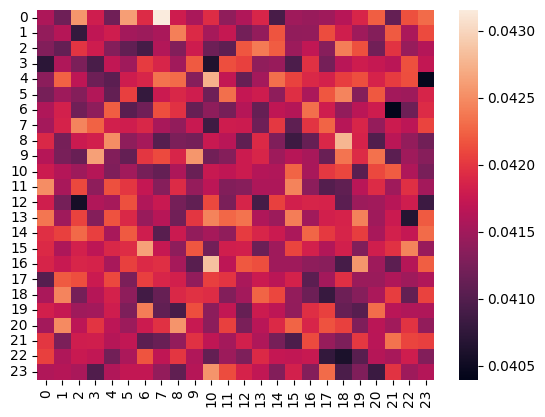

In [3]:
# sns.heatmap(A)
sns.heatmap(cA)


#### Following loop is compatible with the first toy models - / ! \ for Dedieu model I think the clone structure then becomes different... - Need to implement FSM in the decoder/encoders

In [4]:


## Learning loop

#Set up learning loop - question : times ? or no times ? How do I decide for the gradient ? Do I just do one step?? TBD 
import matplotlib.pyplot as plt
'''
E step with a loop, check the time reaquired for convergence
M Step is a 1 time step thing for Transition matrix update
/ ! \ Need to store previous values of the softmax hidden state parametrization for this to work out

To do : 
    - Convergence with dtau = 0.01, It = 25 Inference time
    - What did I really change in the inference to let it converge ?
    - Implement log likelihood each time to follow progress, its change is the indication of learning
'''

##  Log likelihood -- might be wrong idfk yet

def L(Hnow,Hprev,cA): # H's as flattened vectors here
    return np.sum(  Hnow[np.newaxis].T*(np.log(np.sum(cA * Hprev.flatten(),axis=1))[np.newaxis].T + 1 - np.log(Hnow[np.newaxis].T))   )

## Learning parameters

# Learning parameters - 2 time scales
It = 20 # Inference time scale for E step "network balance" 
dtau = 0.01 # Inference learning rate
Lrate = 0.007 # Learning rate for M-step
Time = np.arange(1,len(seq)-1) #Explicit time = sequence length

# Gradient noise - avoid saddles
eps = 1e-3  

# Initialize learning metrics
Inf_params = [np.zeros(shape=(2,1))]
LogL = [] #log likelihood of the model - actually this is the Free energy

for t in tqdm(Time):
    xt = seq[t]
    xt1 = seq[t-1] #temp, issue with initialization
    
    subsetNow = decoder(xt) #row number of current feature
    subsetPrev = decoder(xt1) #row numder of previous feature
    
    ## Prepare for loop on E step - Inference step
    
    balance_time = 0    
    Transition = cA.copy() #For subsetting the transition matrix in inference time scale
    Transition = Transition[subsetNow*n_clones:(subsetNow+1)*n_clones,subsetPrev*n_clones:(subsetPrev+1)*n_clones] #Indices in transition matrix from h go as follows : feature-index*n-clones:feature-index*n-clones + n-clones
    
    
    Inf_params = [np.zeros(shape=(2,1))]
    Inf_h = [h[subsetNow,:].reshape((2,1))] #reshaped as a column for now
    Hprev = h.flatten()
    
    while balance_time < It: # Loop over E step for ssame presentation of stim
        
        balance_time += dtau
        
        #Subset hidden states to get prior estimate, and past estimate
        q = h.copy()
        Qnow = q[subsetNow,:]
        Qprev = q[subsetPrev,:]
        
        Qnow = Qnow[np.newaxis].T #col
        Qprev = Qprev[np.newaxis].T #col
        

        
        #Compute inference gradient and update state space parametization in clones that are concerned (subsetNow)
        grad_h = dtau*dh(Qnow,Qprev,Transition)  #with noise
        grad_h_noisy = grad_h + np.ones(shape=grad_h.shape)*eps
        
        Inf_params.append(Inf_params[-1] + grad_h)
        # print(f'dh is {dh(Qnow,Qprev,Transition)}')
        h_params[subsetNow,:] += grad_h.flatten()
        
        

        
        #Update state space according to inference step
        h = sc.special.softmax(h_params,axis=1) #Update h after having updated the parameters
        Inf_h.append(h[subsetNow,:].reshape((2,1)))
    

        # if np.all(Inf_h[-2]-Inf_h[-1] < np.ones(shape=Inf_h[-1].shape)*10E-6): #I will fix this once convergent behavior actually occurs
        #     # plt.plot(np.arange(0,len(conv_inf)),conv_inf)
        #     # plt.show()
        #     break
    
    
    # Check convergence
    # Inf_params = np.concatenate(Inf_params,axis=1)
    # Convergence_Params = Inf_params[0]
    
    # Inf_h = np.concatenate(Inf_h,axis=1)
    # Convergence = Inf_h[0]
    # Conv_X = np.arange(0,Convergence.shape[0])
    
    # fig,ax = plt.subplots(ncols=2,nrows=1)
    # ax[0].plot(Conv_X,Convergence,label='Latent state')
    # ax[0].set_ylim((0,1))
    # ax[1].plot(Conv_X,Convergence_Params,label='Parameter state')
    
    # fig.suptitle(f'x(t) = {seq[t]}')
    # fig.tight_layout()
    # plt.show()
    
    ''' Learn Transition matrix '''
    
    ''' Option with dilated time '''
    # q = h.copy()
    # Qnow = q[subsetNow,:]
    # Qprev = q[subsetPrev,:]
    # Qnow = Qnow[np.newaxis].T #col
    # Qprev = Qprev[np.newaxis].T #col
    # global_time_step = 0
    # while global_time_step < 1:   #Euler's on one time step in the global CHECK WITH FABIAN IF THIS MAKES SENSE? 
            
    #     Transition = cA.copy() #For subsetting the transition matrix in inference time scale
    #     Transition = Transition[subsetNow*n_clones:(subsetNow+1)*n_clones,subsetPrev*n_clones:(subsetPrev+1)*n_clones] #Indices in transition matrix from h go as follows : feature-index*n-clones:feature-index*n-clones + n-clones
        
        
    #     a[subsetNow*n_clones:(subsetNow+1)*n_clones,subsetPrev*n_clones:(subsetPrev+1)*n_clones] += dt*da(Qnow,Qprev,Transition)
    #     cA = sc.special.softmax(a,axis=1)#change subset of concerned portion of the transition matrix - how do I update this thing ? check my equations to see if it looks like it'll make sense
        
    #     global_time_step += dt

    q = h.copy()
    Qnow = q[subsetNow,:]
    Qprev = q[subsetPrev,:]
    Qnow = Qnow[np.newaxis].T #col
    Qprev = Qprev[np.newaxis].T #col

    Transition = cA.copy() #For subsetting the transition matrix in inference time scale
    Transition = Transition[subsetNow*n_clones:(subsetNow+1)*n_clones,subsetPrev*n_clones:(subsetPrev+1)*n_clones] #Indices in transition matrix from h go as follows : feature-index*n-clones:feature-index*n-clones + n-clones
    
    ''' Current issue is with the transition matrix update. Not Converging to the right matrix. I'd even say its doing the opposite lol Also super sensitive to initial conditions '''
    grad_a = da(Qnow,Qprev,Transition) 
    grad_a_noisy = grad_a + np.ones(shape=grad_a.shape)*eps
    
    a[subsetNow*n_clones:(subsetNow+1)*n_clones,subsetPrev*n_clones:(subsetPrev+1)*n_clones] += Lrate*grad_a_noisy  #change subset of concerned portion of the transition matrix - how do I update this thing ? check my equations to see if it looks like it'll make sense
    
    #Update transition matrix w/ new parameters : 
    cA = sc.special.softmax(a,axis=0)


    ''' Compute log-likelihood and store it '''
    Hnow = h.flatten()
    LogL.append(L(Hnow,Hprev,cA))

    



  0%|          | 0/9 [00:00<?, ?it/s]


IndexError: too many indices for array: array is 1-dimensional, but 2 were indexed

#### Side by side transition matrices

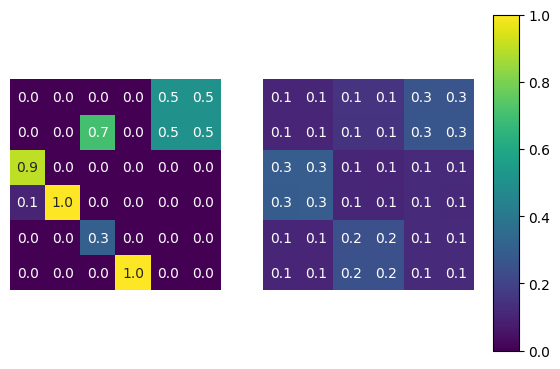

In [ ]:
## Plot Transition matrix learning

'''
Plot 2 transition matrices side by side for result

Current notes : Where the model is supposed to give weight, it actually takes it away. Real transitions are becoming less likely. Local minimum or equation is shit? 

'''
import matplotlib.pyplot as plt
fig, ax = plt.subplots(nrows=1,ncols=2)
sns.heatmap(A,cmap='viridis',vmin=0,vmax=1,ax=ax[0], cbar=False,square=True,annot=True,fmt='.1f',xticklabels=False, yticklabels=False)
matCB = sns.heatmap(cA,cmap='viridis',vmin=0,vmax=1,ax=ax[1], cbar=False,square=True,annot=True,fmt='.1f',xticklabels=False, yticklabels=False)
# matCB = ax[1].matshow(cA,cmap='viridis',vmin=0,vmax=1)

# add space for colour bar
fig.subplots_adjust(right=0.85)
cbar_ax = fig.add_axes([0.88, 0.15, 0.04, 0.7])
fig.colorbar(matCB.get_children()[0], cax=cbar_ax)




#### Plot LogL of the model

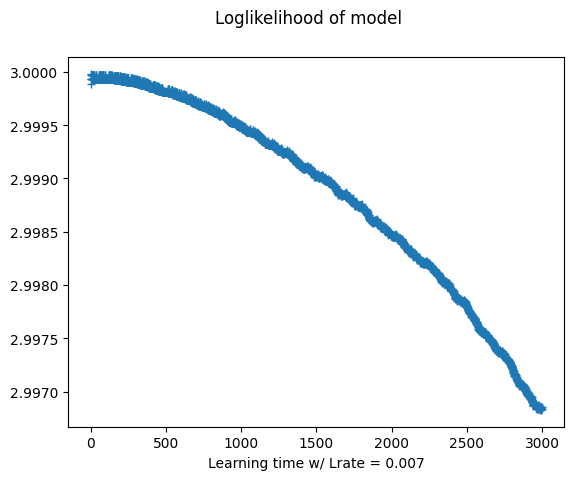

' L = E(joint) - Dkl(prior,true prior)\nActually, this is the evidence lower bound, not the log likelihood exactly - Basically model energy.\n: maybe compute it too to have it plotted, if possible. Otherwise plot model entropy only    \n'

In [ ]:
## Plot log likelihood of the model

# %matplotlib widget
import matplotlib.pyplot as plt
plt.close()
plt.plot(np.arange(0,Time[-1],step=1),LogL,'+')
plt.suptitle('Loglikelihood of model')
plt.xlabel(f'Learning time w/ Lrate = {Lrate}')
plt.show()

''' L = E(joint) - Dkl(prior,true prior)
Actually, this is the evidence lower bound, not the log likelihood exactly - Basically model energy.
: maybe compute it too to have it plotted, if possible. Otherwise plot model entropy only    
'''

In [ ]:
## Store for tests